# Exploración de datos - STARWARS_AUTOCALLS

Revisión previa al modelado: datos, relaciones entre variables, evitar leakage


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

DATA = "../data"
rfqs = pd.read_csv(f"{DATA}/rfqs.csv")
vol = pd.read_csv(f"{DATA}/daily_volatility.csv")
ref = pd.read_csv(f"{DATA}/underlyings_reference.csv")

for nombre, df in [("rfqs", rfqs), ("vol", vol), ("ref", ref)]:
    print(f"{nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")


rfqs: 25000 filas x 17 columnas
vol: 44744 filas x 3 columnas
ref: 14 filas x 3 columnas


## 1. Inventario


In [9]:
print(rfqs.dtypes)
print()
print(rfqs["underlyings"].head(5).tolist())


rfq_id                        str
product_type                  str
underlyings                   str
basket_type                   str
autocall_barrier_pct      float64
protection_barrier_pct    float64
no_call_period_months       int64
observation_frequency         str
quoted_implied_vol        float64
notional_credits            int64
counterparty                  str
trader_id                     str
requested_date                str
executed                     bool
start_date                    str
end_date                      str
avg_duration_months       float64
dtype: object

['CLNE|DRC', 'SITH|WOOK', 'MNDO|NABO', 'TECH|SITH', 'JEDI']


In [10]:
print(vol.head(3))
print()
print(ref)


         date underlying  realized_vol_63d
0  2014-04-01       KYBR          0.194111
1  2014-04-02       KYBR          0.186989
2  2014-04-03       KYBR          0.188895

   underlying                              sector  structural_base_vol
0        KYBR  Mineria de materiales estrategicos                 0.22
1        CORL              Logistica y transporte                 0.28
2        MNDO                 Defensa y armamento                 0.35
3        HTTX          Comercio y materias primas                 0.50
4        TECH         Tecnologia y automatizacion                 0.32
5        SITH          Energia e infraestructuras                 0.26
6        JEDI                 Gestion patrimonial                 0.14
7        BSKR                Metales y aleaciones                 0.30
8        POBK              Ocio y entretenimiento                 0.42
9        NABO         Agricultura y biotecnologia                 0.11
10       REBL             Renta fija especulat

In [12]:
for nombre, df in [("rfqs", rfqs), ("vol", vol), ("ref", ref)]:
    n = df.isna().sum()
    n = n[n > 0]
    print(f"--- {nombre} ---")
    print(n if len(n) else "sin nulos")
    print()

falta = rfqs["avg_duration_months"].isna()
print(f"filas sin variable objetivo: {falta.sum()} ({falta.mean():.1%})")


--- rfqs ---
avg_duration_months    11204
dtype: int64

--- vol ---
sin nulos

--- ref ---
sin nulos

filas sin variable objetivo: 11204 (44.8%)


In [13]:
# Los nulos del target coinciden con las RFQs no ejecutadas?
print(rfqs.groupby("executed")["avg_duration_months"].apply(lambda s: s.isna().mean()))


executed
False    1.0
True     0.0
Name: avg_duration_months, dtype: float64


In [14]:
print("rfqs, filas identicas:", rfqs.duplicated().sum())
print("rfq_id unico:", rfqs["rfq_id"].is_unique)
print("vol duplicados por (date, underlying):", vol.duplicated(["date", "underlying"]).sum())
print("ref duplicados por underlying:", ref.duplicated(["underlying"]).sum())


rfqs, filas identicas: 0
rfq_id unico: True
vol duplicados por (date, underlying): 0
ref duplicados por underlying: 0


Fechas como texto, hay que parsearlas.

`underlyings` mete varios tickers en una celda. Habrá que explotarla para poder
cruzar con las tablas de mercado.

Las tres tablas tienen grano distinto. Una fila por solicitud, una por activo y
día, una por activo. No unen directamente.

Nulos solo en el target, 11.204 filas (45%). Coinciden exactamente con
`executed = False`. Si el producto no llegó a emitirse no hay duración que
observar, así que no imputo. Salen del entrenamiento pero las guardo para
mirar sesgo de selección.

Sin duplicados y las claves declaradas se cumplen.


## 2. Variables categóricas


In [15]:
cats = ["product_type", "basket_type", "observation_frequency",
        "counterparty", "trader_id", "executed"]

for c in cats:
    vc = rfqs[c].value_counts()
    print(f"--- {c}: {len(vc)} categorias ---")
    print(vc.to_string())
    print()


--- product_type: 6 categorias ---
product_type
Holocron Reverse Convertible    4245
Mandalorian Twin-Win            4216
Wretched Hive Digital           4167
Sith Eternal Snowball           4160
Death Star Phoenix Note         4148
Kessel Run Snowball             4064

--- basket_type: 2 categorias ---
basket_type
worst_of    16539
single       8461

--- observation_frequency: 18 categorias ---
observation_frequency
1M            6174
3M            5298
6M            3618
2M            1995
1Y            1601
1D             711
Monthly        670
mensual        667
1 month        658
M              651
Quarterly      576
trimestral     570
Q              566
3 months       559
12M            191
Y              175
Annual         164
anual          156

--- counterparty: 8 categorias ---
counterparty
Corellian Capital           3195
Kamino Cloning Trust        3160
Banco de Coruscant          3157
Chandrila Sovereign Fund    3125
Alderaan Wealth Partners    3111
First Order Financial  

`observation_frequency` tiene 18 etiquetas para 6 frecuencias reales. (`1M`, `M`,
`Monthly`, `mensual`, `1 month`).

Las unifico con un diccionario y las paso a meses entre observaciones. Como
categorías sueltas el modelo perdería el orden y la magnitud, para él `1M` y
`2M` serían tan distintas como dos contrapartes cualquiera.

De ahí saco `n_oportunidades = (vida_nominal - no_call) / meses_entre_obs`.
Lo que mueve la duración no es cada cuánto se observa sino cuántas veces puede
llegar a cancelarse el producto.

`counterparty` (8) y `trader_id` (39) están repartidas casi uniformemente, pero
eso solo dice que hay un número parecido de RFQs por grupo. Si se comportan
distinto o no es otra cosa y lo compruebo aparte.


In [16]:
ex = rfqs[rfqs["executed"]].copy()

print(ex.groupby("counterparty")["avg_duration_months"].agg(["count", "mean", "std"]).round(2).to_string())
print()
print(ex.groupby("trader_id")["avg_duration_months"].agg(["count", "mean"]).round(2).sort_values("mean").to_string())


                          count   mean    std
counterparty                                 
Alderaan Wealth Partners   1738  40.28  22.60
Banco de Coruscant         1741  39.28  21.52
Chandrila Sovereign Fund   1722  39.97  21.59
Corellian Capital          1743  40.03  22.12
First Order Financial      1733  39.50  21.89
Jabba Asset Management     1705  39.09  22.06
Kamino Cloning Trust       1769  40.26  22.51
Nal Hutta Traders          1645  39.82  22.53

           count   mean
trader_id              
TRD-034      322  35.76
TRD-014      360  36.63
TRD-004      317  37.36
TRD-010      366  37.56
TRD-030      329  37.79
TRD-018      382  38.38
TRD-015      339  38.57
TRD-005      383  38.74
TRD-023      374  38.75
TRD-007      339  38.81
TRD-029      342  38.92
TRD-027      334  39.15
TRD-008      347  39.31
TRD-024      363  39.35
TRD-022      375  39.39
TRD-019      338  39.60
TRD-002      356  39.63
TRD-009      363  39.70
TRD-012      344  39.79
TRD-033      309  39.93
TRD-013    

In [30]:
print("sd global del target:", round(ex["avg_duration_months"].std(), 2))
print()
for c in ["counterparty", "trader_id"]:
    grupos = [g["avg_duration_months"].values for _, g in ex.groupby(c)]
    f, p = stats.f_oneway(*grupos)
    k, n = len(grupos), len(ex)
    eta2 = (f * (k - 1)) / (f * (k - 1) + (n - k))   # tamaño del efecto a partir de F
    print(f"{c}: F={f:.2f}  p={p:.4f}  eta2={eta2*100:.2f}%")


sd global del target: 22.11

counterparty: F=0.70  p=0.6739  eta2=0.04%
trader_id: F=1.58  p=0.0134  eta2=0.43%


`counterparty` no muestra señal.

`trader_id` sale significativo (p = 0,013) pero explica el 0,43% de la varianza.
Con casi 14.000 observaciones el contraste detecta diferencias irrelevantes.

Descarto las dos. La señal es marginal frente a una desviación global de 22
meses y probablemente viene del tipo de producto que cada uno cotiza, que ya
está en el modelo. Además `trader_id` haría que el modelo dependiera de
categorías que pueden no existir en producción, un trader nuevo rompería la
predicción.


## 3. Variables numéricas


In [18]:
print(rfqs.describe().T)


                          count           mean           std          min          25%           50%          75%           max
autocall_barrier_pct    25000.0       1.139004  1.472571e-01       0.9500       1.0000       1.15270       1.2761  1.400000e+00
protection_barrier_pct  25000.0       0.663538  9.647306e-02       0.5000       0.6000       0.62250       0.7609  8.500000e-01
no_call_period_months   25000.0       1.480160  2.016732e+00       0.0000       0.0000       0.00000       3.0000  6.000000e+00
quoted_implied_vol      25000.0       0.278661  8.905546e-02       0.0936       0.2177       0.27425       0.3305  5.997000e-01
notional_credits        25000.0  676412.000000  1.695565e+06  100000.0000  100000.0000  250000.00000  500000.0000  2.000000e+07
avg_duration_months     13796.0      39.782783  2.210513e+01       0.1600      23.5675      35.38000      51.9525  1.277100e+02


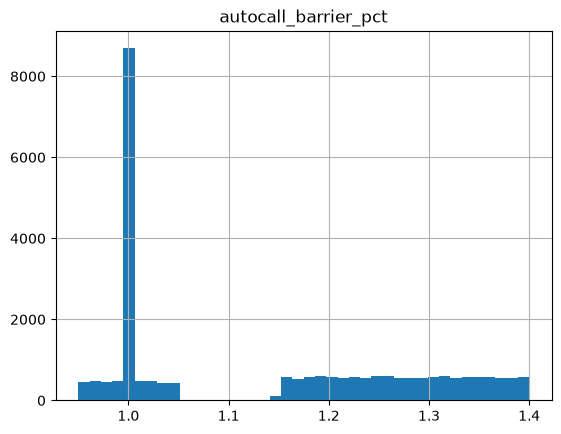

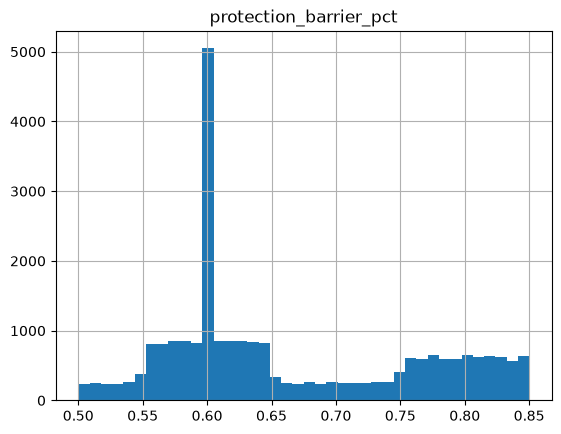

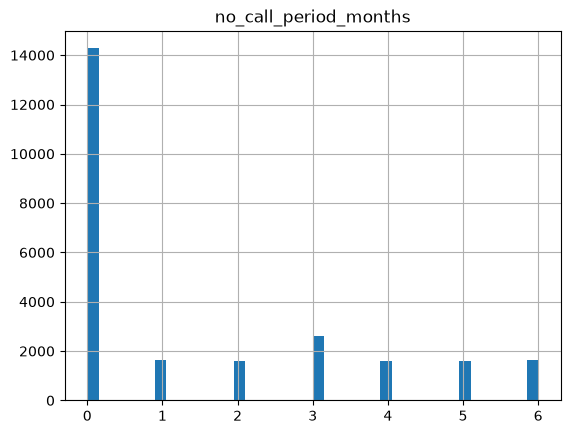

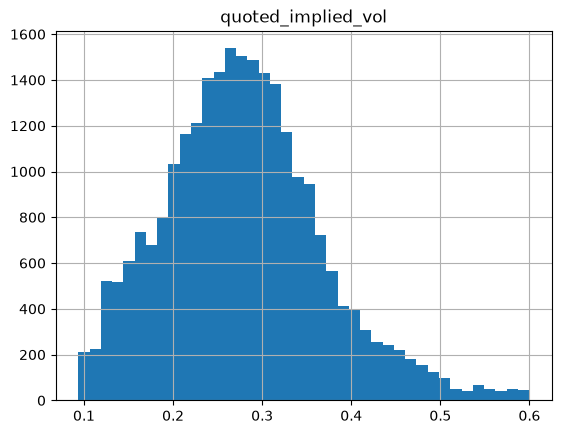

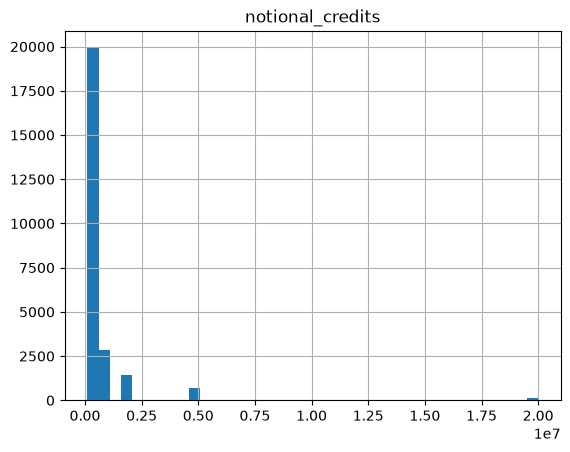

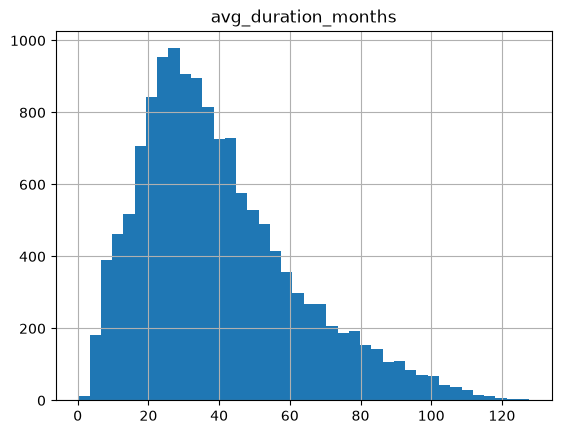

In [19]:
for c in rfqs.select_dtypes("number").columns:
    rfqs[c].hist(bins=40)
    plt.title(c)
    plt.show()


In [20]:
print(rfqs["notional_credits"].value_counts().sort_index().to_string())


notional_credits
100000      8018
250000      7024
500000      4859
1000000     2826
2000000     1456
5000000      677
20000000     140


In [21]:
# Los productos mas cortos, son errores o tienen explicacion?
cortos = ex[ex["avg_duration_months"] < 1]
print(f"duracion < 1 mes: {len(cortos)} productos")
print(cortos[["product_type", "observation_frequency", "autocall_barrier_pct",
              "no_call_period_months", "avg_duration_months"]].to_string(index=False))


duracion < 1 mes: 2 productos
           product_type observation_frequency  autocall_barrier_pct  no_call_period_months  avg_duration_months
Death Star Phoenix Note                    1D                0.9676                      0                 0.24
Death Star Phoenix Note                    1D                0.9679                      0                 0.16


In [22]:
# Varias distribuciones son multimodales o tienen huecos, vienen del tipo de producto?
for c in ["autocall_barrier_pct", "protection_barrier_pct", "no_call_period_months"]:
    print(f"--- {c} por product_type ---")
    print(rfqs.groupby("product_type")[c].agg(["min", "max", "nunique"]).to_string())
    print()


--- autocall_barrier_pct por product_type ---
                                 min     max  nunique
product_type                                         
Death Star Phoenix Note       0.9500  1.0500      983
Holocron Reverse Convertible  1.1501  1.3999     2042
Kessel Run Snowball           1.0000  1.0000        1
Mandalorian Twin-Win          1.1500  1.4000     2033
Sith Eternal Snowball         1.0000  1.0000        1
Wretched Hive Digital         1.1501  1.3999     2021

--- protection_barrier_pct por product_type ---
                                 min   max  nunique
product_type                                       
Death Star Phoenix Note       0.5500  0.70     1400
Holocron Reverse Convertible  0.7000  0.85     1418
Kessel Run Snowball           0.5000  0.65     1398
Mandalorian Twin-Win          0.7501  0.85      992
Sith Eternal Snowball         0.5500  0.65      987
Wretched Hive Digital         0.6000  0.60        1

--- no_call_period_months por product_type ---
         

`notional_credits` no es continua, solo toma 7 valores espaciados en escala
logarítmica. Son los tamaños estándar de operación de la mesa, así que el
histograma que parece sesgado son en realidad 7 escalones.

`autocall_barrier_pct` es trimodal y tiene un hueco vacío entre 1,05 y 1,15.
`protection_barrier_pct` tiene un pico marcado en 0,60. `no_call_period_months`
es discreta y más de la mitad son cero.

Cruzando por `product_type` se explica todo. El tipo de producto funciona como
plantilla de contrato y fija el rango, a veces el valor exacto, del resto de
parámetros. Kessel Run y Sith Eternal llevan siempre barrera en 1,00. Wretched
Hive lleva siempre protección en 0,60. Holocron, Mandalorian y Wretched Hive
llevan siempre `no_call_period = 0`. El hueco entre 1,05 y 1,15 está vacío
porque ninguna familia usa ese rango.

Dos consecuencias. Hay redundancia entre `product_type` y los parámetros del
contrato. Y una correlación aparente con un parámetro puede ser en realidad con
el tipo de producto, cosa que hay que comprobar antes de fiarse.

Los dos productos que duran menos de un mes son observación diaria, sin no-call
y con barrera al 96,8%, por debajo del nivel inicial. Cualquier subida los
cancela y pueden observar todos los días, así que son plausibles.

## 4. Fechas y coherencia de negocio


In [23]:
for c in ["requested_date", "start_date", "end_date"]:
    rfqs[c] = pd.to_datetime(rfqs[c])
vol["date"] = pd.to_datetime(vol["date"])

for c in ["requested_date", "start_date", "end_date"]:
    print(f"{c}: {rfqs[c].min().date()} -> {rfqs[c].max().date()}")
print(f"vol.date:       {vol['date'].min().date()} -> {vol['date'].max().date()}")
print()
print(rfqs.groupby(rfqs["requested_date"].dt.year).size().to_string())


requested_date: 2016-01-04 -> 2024-06-28
start_date: 2016-01-04 -> 2024-07-03
end_date: 2018-01-25 -> 2034-05-27
vol.date:       2014-04-01 -> 2026-06-30

requested_date
2016    2988
2017    2894
2018    2869
2019    2984
2020    2926
2021    3002
2022    2934
2023    2970
2024    1433


In [24]:
# 2024 tiene la mitad de RFQs, esta truncado o cayo la actividad?
print(rfqs[rfqs["requested_date"].dt.year == 2024]
      .groupby(rfqs["requested_date"].dt.month).size().to_string())
print("\nultima RFQ:", rfqs["requested_date"].max().date())


requested_date
1    224
2    233
3    214
4    272
5    273
6    217

ultima RFQ: 2024-06-28


In [25]:
rfqs["vida_nominal_meses"] = (
    (rfqs["end_date"].dt.year - rfqs["start_date"].dt.year) * 12
    + (rfqs["end_date"].dt.month - rfqs["start_date"].dt.month)
)
ex = rfqs[rfqs["executed"]].copy()

# Reglas que deben cumplirse por la definicion del producto
print("requested > start:", (rfqs["requested_date"] > rfqs["start_date"]).sum())
print("start > end:", (rfqs["start_date"] > rfqs["end_date"]).sum())
print("duracion < no_call_period:", (ex["avg_duration_months"] < ex["no_call_period_months"]).sum())
print("proteccion >= autocall:", (rfqs["protection_barrier_pct"] >= rfqs["autocall_barrier_pct"]).sum())
print("no_call > vida nominal:", (rfqs["no_call_period_months"] > rfqs["vida_nominal_meses"]).sum())
print("vol implicita <= 0:", (rfqs["quoted_implied_vol"] <= 0).sum())
print("vol realizada <= 0:", (vol["realized_vol_63d"] <= 0).sum())
print("RFQs sin cotizacion de vol en su fecha:",
      (~rfqs["requested_date"].isin(set(vol["date"]))).sum())
print()
print(pd.crosstab(rfqs["basket_type"], rfqs["underlyings"].str.count(r"\|") + 1))


requested > start: 0
start > end: 0
duracion < no_call_period: 0
proteccion >= autocall: 0
no_call > vida nominal: 0
vol implicita <= 0: 0
vol realizada <= 0: 0
RFQs sin cotizacion de vol en su fecha: 0

underlyings     1      2     3
basket_type                   
single       8461      0     0
worst_of        0  12379  4160


In [26]:
# La duracion no puede superar la vida nominal del producto
ex["exceso"] = ex["avg_duration_months"] - ex["vida_nominal_meses"]
ex["mala"] = ex["exceso"] > 0
print(f"duracion > vida nominal: {ex['mala'].sum()} filas ({ex['mala'].mean():.2%})")
print(ex.loc[ex["mala"], "exceso"].describe().round(2).to_string())


duracion > vida nominal: 303 filas (2.20%)
count    303.00
mean       2.40
std        2.39
min        0.01
25%        0.68
50%        1.54
75%        3.36
max       13.40


In [28]:
# Son aleatorias o siguen un patron?
print("tasa por product_type")
print(ex.groupby("product_type")["mala"].agg(["sum", "mean"]).round(4).to_string())
print()
print("tasa por año")
print(ex.groupby(ex["requested_date"].dt.year)["mala"].mean().round(4).to_string())
print()
print("exceso medio de las filas malas, por producto")
print(ex[ex["mala"]].groupby("product_type")["exceso"].mean().round(2).to_string())


tasa por product_type
                              sum    mean
product_type                             
Death Star Phoenix Note         8  0.0035
Holocron Reverse Convertible    6  0.0025
Kessel Run Snowball            14  0.0063
Mandalorian Twin-Win           12  0.0052
Sith Eternal Snowball          50  0.0217
Wretched Hive Digital         213  0.0917

tasa por año
requested_date
2016    0.0231
2017    0.0244
2018    0.0172
2019    0.0261
2020    0.0210
2021    0.0266
2022    0.0222
2023    0.0198
2024    0.0107

exceso medio de las filas malas, por producto
product_type
Death Star Phoenix Note         3.52
Holocron Reverse Convertible    1.00
Kessel Run Snowball             1.26
Mandalorian Twin-Win            1.37
Sith Eternal Snowball           2.20
Wretched Hive Digital           2.58


Fechas coherentes, `requested <= start <= end` en las 25.000 filas.

2024 tiene la mitad de RFQs porque está truncado. Hay datos de enero a junio con
volumen mensual normal y la última solicitud es del 28 de junio, o sea que es el
corte de extracción y no una caída de actividad.

Todas las RFQs caen en día con cotización de volatilidad, así que el cruce puede
hacerse por fecha exacta sin buscar el día hábil anterior.

De las nueve reglas de negocio que compruebo, ocho se cumplen siempre. Falla que
la duración no puede superar la vida nominal, en 303 filas (2,2%).

Y no es aleatorio. Se concentra en Wretched Hive Digital, con un 9,2% de sus
filas frente a menos del 2,2% en el resto, y encima con excesos mayores. Por año
no hay patrón.

Elimino esas 303 filas porque son imposibles y enseñarían al modelo una relación
que no puede darse. Pero el patrón apunta a un fallo en la simulación de ese
producto, así que lo reportaría al equipo de datos en vez de tratarlo solo como
limpieza.

## 5. Relaciones entre variables

Antes de calcular nada, lo que espero por la definición del producto.

| Variable | Efecto esperado sobre la duración |
|---|---|
| `vida_nominal_meses` | ++ acota la duración máxima posible |
| `autocall_barrier_pct` | + barrera más alta, más difícil de superar, dura más |
| `no_call_period_months` | + impone un suelo a la duración |
| `quoted_implied_vol` | - en `single`, + en `worst_of` |
| `protection_barrier_pct` | ninguno, actúa al vencimiento y no en la cancelación |
| `notional_credits` | ninguno |


In [32]:
ex = rfqs[rfqs["executed"] & (rfqs["avg_duration_months"] <= rfqs["vida_nominal_meses"])].copy()
print("filas:", len(ex))
print()

num = ["autocall_barrier_pct", "protection_barrier_pct", "no_call_period_months",
       "quoted_implied_vol", "notional_credits", "vida_nominal_meses"]
print(ex[num + ["avg_duration_months"]].corr(method="spearman")["avg_duration_months"].sort_values().to_string())


filas: 13493

protection_barrier_pct   -0.324271
quoted_implied_vol       -0.064203
autocall_barrier_pct     -0.019344
notional_credits         -0.003104
no_call_period_months     0.117745
vida_nominal_meses        0.514989
avg_duration_months       1.000000


In [33]:
# Tres correlaciones contradicen lo esperado, se mantienen dentro de cada producto?
def corr_por_grupo(df, x, grupo, y="avg_duration_months"):
    return df.groupby(grupo)[[x, y]].apply(
        lambda g: g.corr(method="spearman").iloc[0, 1]).round(3)

for v in ["protection_barrier_pct", "autocall_barrier_pct", "quoted_implied_vol"]:
    print(f"--- {v} ---")
    print(corr_por_grupo(ex, v, "product_type").to_string())
    print()


--- protection_barrier_pct ---
product_type
Death Star Phoenix Note        -0.027
Holocron Reverse Convertible    0.009
Kessel Run Snowball            -0.008
Mandalorian Twin-Win            0.008
Sith Eternal Snowball          -0.022
Wretched Hive Digital             NaN

--- autocall_barrier_pct ---
product_type
Death Star Phoenix Note         0.252
Holocron Reverse Convertible    0.179
Kessel Run Snowball               NaN
Mandalorian Twin-Win            0.205
Sith Eternal Snowball             NaN
Wretched Hive Digital           0.114

--- quoted_implied_vol ---
product_type
Death Star Phoenix Note         0.278
Holocron Reverse Convertible   -0.510
Kessel Run Snowball             0.320
Mandalorian Twin-Win           -0.509
Sith Eternal Snowball           0.253
Wretched Hive Digital           0.010



In [34]:
print(corr_por_grupo(ex, "quoted_implied_vol", "basket_type").to_string())
print()
print(pd.crosstab(ex["product_type"], ex["basket_type"]))


basket_type
single     -0.510
worst_of    0.203

basket_type                   single  worst_of
product_type                                  
Death Star Phoenix Note            0      2275
Holocron Reverse Convertible    2361         0
Kessel Run Snowball                0      2205
Mandalorian Twin-Win            2287         0
Sith Eternal Snowball              0      2254
Wretched Hive Digital              0      2111


Tres correlaciones globales contradicen la lógica del producto y las tres por el
mismo motivo. Mezclan seis tipos de producto con rangos de parámetros y
comportamientos distintos. Al condicionar por `product_type` salen tres
patrones diferentes.

**`protection_barrier_pct` es espuria.** Global -0,32, pero dentro de cada
producto queda entre -0,03 y +0,01. Desaparece. Cada producto tiene su banda de
protección y su duración media propia, con lo que la variable funcionaba como
identificador encubierto del tipo de producto. Paradoja de Simpson. La descarto.

**`autocall_barrier_pct` tenía el efecto enmascarado.** Global -0,02, pero entre
+0,11 y +0,25 en los cuatro productos donde varía. En los dos Snowball es
constante y sale `NaN`. Se ocultaba porque cada familia ocupa una banda distinta
de barrera y tiene distinta duración media.

**`quoted_implied_vol` cambia de signo según el tipo de cesta.** -0,51 en
`single` y +0,20 en `worst_of`. Con un solo subyacente más volatilidad hace más
probable superar la barrera, así que cancela antes. En un `worst_of` se mira el
peor activo de la cesta, y más dispersión hunde al mínimo alejándolo de la
barrera superior, así que dura más. La correlación global es casi nula porque
los dos efectos se cancelan al promediarse.

Esto decide la elección de modelo. Un lineal asigna un único coeficiente a la
volatilidad y esos dos efectos opuestos lo llevan a cero. Un modelo de árboles
segmenta por `basket_type` y aprende el efecto correcto en cada rama sin que
haya que especificar la interacción.

El crosstab confirma además que `product_type` determina completamente a
`basket_type`. Aun siendo redundante lo conservo, porque expresa esa interacción
en una sola partición binaria en vez de exigir agrupar seis categorías.

## 6. Qué se conoce al cotizar

Una columna solo puede ser feature si su valor existe cuando la mesa cotiza la
RFQ. Todo lo demás es leakage, aunque mejore la métrica en validación.


| Columna | ¿Disponible al cotizar? |
|---|---|
| `product_type`, `underlyings`, `basket_type` | Sí |
| `autocall_barrier_pct`, `no_call_period_months` | Sí |
| `observation_frequency`, `quoted_implied_vol` | Sí |
| `start_date`, `end_date` | Sí, términos pactados |
| `protection_barrier_pct`, `notional_credits` | Sí, pero descartadas |
| `counterparty`, `trader_id` | Sí, pero descartadas |
| `requested_date` | Sí, para el split y el cruce, no como feature |
| `executed` | No, criterio de selección |
| `avg_duration_months` | No, es el target |

In [36]:
# El enunciado dice que start_date y end_date solo existen si executed = True
no_ex = rfqs[~rfqs["executed"]]
print("no ejecutadas:", len(no_ex))
print("  con start_date:", no_ex["start_date"].notna().sum())
print("  con end_date:", no_ex["end_date"].notna().sum())
print()
print("desfase requested -> start (dias):")
print((rfqs["start_date"] - rfqs["requested_date"]).dt.days.describe().round(2).to_string())


no ejecutadas: 11204
  con start_date: 11204
  con end_date: 11204

desfase requested -> start (dias):
count    25000.00
mean         1.39
std          1.78
min          0.00
25%          0.00
50%          0.00
75%          3.00
max          5.00


`executed` no es feature sino criterio de selección de muestra. Al cotizar no
se sabe si el cliente aceptará el precio.

`start_date` y `end_date` sí son utilizables aunque parezcan leakage. `end_date`
es el vencimiento nominal pactado, no la fecha en que acabó el producto. La
prueba es que las 11.204 RFQs no ejecutadas también las tienen, o sea que
existen antes de que el producto se emita. Y el desfase entre solicitud e inicio
es de 0 a 5 días. Esto legitima `vida_nominal_meses`, la variable más
correlacionada con el target.

El enunciado dice que esas dos fechas solo existen si `executed = True`, pero
los datos lo contradicen.

`requested_date` la uso para el split temporal y como fecha de corte del cruce,
no como feature. Los árboles no extrapolan, así que en producción todas las
fechas caerían fuera del rango entrenado y siempre en la última hoja.

El riesgo principal está en el cruce con mercado. La volatilidad llega a junio
de 2026 y la última RFQ es de junio de 2024, o sea dos años de datos posteriores
a cualquier solicitud. Un merge sin restricción temporal metería volatilidad
futura como predictor. Lo resuelvo con `merge_asof(direction="backward")` y un
test que lo comprueba.

`structural_base_vol` es leakage potencial de baja severidad. Es una estimación
estática sin fecha, así que si se calibró con el histórico completo incorpora
información posterior a las RFQs antiguas. No verificable con estos datos.

## 7. Sesgo de selección

Solo el 55% de las RFQs tiene target. Si ejecutarse dependiera de las
características del producto, el modelo aprendería de una submuestra sesgada.


In [37]:
comp = []
for c in ["autocall_barrier_pct", "protection_barrier_pct", "no_call_period_months",
          "quoted_implied_vol", "notional_credits", "vida_nominal_meses"]:
    g = rfqs.groupby("executed")[c].mean()
    comp.append({"variable": c, "no_ejecutadas": g[False], "ejecutadas": g[True]})
print(pd.DataFrame(comp).round(4).to_string(index=False))


              variable  no_ejecutadas  ejecutadas
  autocall_barrier_pct         1.1379      1.1399
protection_barrier_pct         0.6636      0.6635
 no_call_period_months         1.4871      1.4745
    quoted_implied_vol         0.2788      0.2785
      notional_credits    704025.3481 653986.6628
    vida_nominal_meses        71.8844     71.9530


In [38]:
for c in ["product_type", "basket_type", "observation_frequency", "counterparty"]:
    tab = pd.crosstab(rfqs[c], rfqs["executed"])
    chi2, p, _, _ = stats.chi2_contingency(tab)
    print(f"{c:24s} chi2={chi2:6.2f}  p={p:.4f}")


product_type             chi2=  2.54  p=0.7705
basket_type              chi2=  0.00  p=0.9439
observation_frequency    chi2= 21.36  p=0.2106
counterparty             chi2=  5.58  p=0.5896


Las medias de ejecutadas y no ejecutadas son prácticamente idénticas y ninguna
de las cuatro categóricas muestra asociación con `executed`. La submuestra con
target es representativa.

Solo puedo descartar sesgo sobre variables observables. Si ejecutarse dependiera
del precio cotizado o de la negociación con el cliente, que no están en estas
tablas, el sesgo existiría y no lo vería.

## 8. Integración de las tres tablas


In [39]:
tickers = set()
for u in rfqs["underlyings"]:
    tickers.update(u.split("|"))

print("tickers en rfqs:", len(tickers))
print("sin fila en referencia:", tickers - set(ref["underlying"]))
print("sin datos de volatilidad:", tickers - set(vol["underlying"]))
print()
print("tamaño de cesta:")
print((rfqs["underlyings"].str.count(r"\|") + 1).value_counts().sort_index().to_string())
print()
print("dias de cotizacion por subyacente:")
print(vol.groupby("underlying")["date"].count().describe()[["min", "max"]].to_string())


tickers en rfqs: 14
sin fila en referencia: set()
sin datos de volatilidad: set()

tamaño de cesta:
underlyings
1     8461
2    12379
3     4160

dias de cotizacion por subyacente:
min    3196.0
max    3196.0


In [40]:
# Las dos fuentes de volatilidad son coherentes entre si?
comp = vol.groupby("underlying")["realized_vol_63d"].mean().round(3).to_frame("vol_realizada")
comp = comp.join(ref.set_index("underlying")[["sector", "structural_base_vol"]])
comp["ratio"] = (comp["vol_realizada"] / comp["structural_base_vol"]).round(2)
print(comp.sort_values("ratio").to_string())


            vol_realizada                              sector  structural_base_vol  ratio
underlying                                                                               
KYBR                0.265  Mineria de materiales estrategicos                 0.22   1.20
POBK                0.507              Ocio y entretenimiento                 0.42   1.21
TECH                0.391         Tecnologia y automatizacion                 0.32   1.22
BSKR                0.365                Metales y aleaciones                 0.30   1.22
MNDO                0.430                 Defensa y armamento                 0.35   1.23
WOOK                0.333                         Manufactura                 0.27   1.23
JEDI                0.172                 Gestion patrimonial                 0.14   1.23
DRC                 0.382              Consumo y distribucion                 0.31   1.23
SITH                0.319          Energia e infraestructuras                 0.26   1.23
CLNE      

In [41]:
# Los dos que se desvian, es una media inflada por episodios puntuales?
for t in ["REBL", "HTTX"]:
    s = vol[vol["underlying"] == t].set_index("date")["realized_vol_63d"]
    print(f"--- {t}, media anual ---")
    print(s.resample("YE").mean().round(3).to_string())
    print()


--- REBL, media anual ---
date
2014-12-31    0.391
2015-12-31    0.582
2016-12-31    0.435
2017-12-31    0.525
2018-12-31    0.343
2019-12-31    0.409
2020-12-31    0.415
2021-12-31    0.658
2022-12-31    0.526
2023-12-31    0.559
2024-12-31    0.362
2025-12-31    0.503
2026-12-31    0.491
Freq: YE-DEC

--- HTTX, media anual ---
date
2014-12-31    0.799
2015-12-31    0.991
2016-12-31    0.756
2017-12-31    0.729
2018-12-31    0.987
2019-12-31    0.680
2020-12-31    1.154
2021-12-31    0.998
2022-12-31    0.756
2023-12-31    0.873
2024-12-31    0.897
2025-12-31    0.854
2026-12-31    0.868
Freq: YE-DEC



Los 14 tickers están en las tres tablas. Cestas de 1 a 3 activos y panel de
volatilidad balanceado, 3.196 días por subyacente sin huecos.

El grano de trabajo es la RFQ. Exploto `underlyings` para tener una fila por
solicitud y activo, cruzo con volatilidad point-in-time y con la referencia por
ticker, y reagrego. En un `worst_of` manda el activo más débil, no el promedio,
así que resumo la cesta con máximo, mínimo, media y desviación.

Doce de los catorce subyacentes tienen un ratio realizada/estructural entre
1,20 y 1,25. Se desvían REBL (2,66) y HTTX (1,75), y mirando la media anual no
es por episodios puntuales: REBL se mueve entre 0,34 y 0,66 y HTTX entre 0,68 y
1,15 los trece años. `structural_base_vol` los infravalora de forma persistente.

Uso la realizada point-in-time como fuente principal y dejo la estructural como
complemento. Lo reportaría al equipo de datos, igual que lo de Wretched Hive.

## Resumen de decisiones

| Hallazgo | Decisión | Justificación |
|---|---|---|
| 11.204 filas sin target (45%) | Excluir del entrenamiento, conservar para analizar sesgo | Nulos estructurales, sin emisión no hay duración |
| 18 etiquetas para 6 frecuencias | Unificar y convertir a meses entre observaciones | Mismo concepto en cuatro formatos distintos |
| La frecuencia como categoría pierde magnitud | Derivar `n_oportunidades` | Importa cuántas veces puede cancelarse, no cada cuánto se observa |
| 303 filas con duración > vida nominal | Eliminar y reportar | Imposible por definición y concentrado en un producto (9,2%) |
| `counterparty` y `trader_id` | Descartar | p = 0,674 y eta2 = 0,43%, y dependerían de categorías nuevas |
| `protection_barrier_pct` correlaciona -0,32 | Descartar | Desaparece al condicionar, es proxy de `product_type` |
| `notional_credits` | Descartar | rho = -0,003 |
| La volatilidad cambia de signo según la cesta | Conservar `basket_type` pese a la redundancia | Codifica la interacción en una sola partición binaria |
| Mercado dos años más allá de la última RFQ | Cruce point-in-time y test automático | Evitar volatilidad futura como predictor |
| Cestas de 1 a 3 activos | Agregar con max, min, media y desviación | En un `worst_of` manda el activo más débil |
| `structural_base_vol` falla en REBL y HTTX | Usar la realizada como fuente principal | La constante infravalora a esos dos de forma persistente |
